# Introduction

This project addresses the business problem of predicting customer behavior — whether a bank client will sign a term deposit within a marketing campaign.

Such tasks directly impact business efficiency: they allow for the optimization of communication costs with clients, increase conversion rates, and better target the audience.

The goal of the work is to build an interpretable machine learning model that not only demonstrates good forecasting quality but also allows for understanding the key factors influencing the client's decision.

Within the project:

- exploratory data analysis was conducted to identify patterns and form hypotheses;
- data preparation and feature engineering were performed considering real constraints (including avoiding data leakage);
- several classification models were trained and compared;
- hyperparameter tuning was carried out to improve model quality;
- feature importance was analyzed and results were interpreted using SHAP;
- model errors were investigated and directions for further improvement were proposed.

The resulting solution demonstrates how data can be used to make informed business decisions and can serve as a basis for further implementation in a production environment.

# Data

The project uses a dataset of the bank's marketing campaigns, available on Kaggle: https://www.kaggle.com/datasets/sahistapatel96/bankadditionalfullcsv

The data contains information about clients, their socio-economic characteristics, as well as their interaction history with the bank within the marketing campaigns.

Target variable:

y — whether the client subscribed to a term deposit (yes / no).

The features can be conditionally divided into several groups:

client characteristics (age, profession, education, marital status); financial status (presence of loans, defaults); campaign contact data (type of communication, number of contacts, previous results); macroeconomic indicators (indices, rates, employment level).

An important feature of the dataset is the presence of the duration feature, which has a strong correlation with the target variable but is not available at the time of prediction. Therefore, it is used only for exploratory analysis and model comparison, but is excluded from the final model.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys
import os

In [ ]:
path_to_module = '/content/drive/MyDrive/ML Course/Portfolio/Bank Marketing'
if path_to_module not in sys.path:
    sys.path.append(path_to_module)
    print(path_to_module)

/content/drive/MyDrive/ML Course/Portfolio/Bank Marketing


In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import utils
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import shap

from sklearn.model_selection import train_test_split, cross_validate, cross_val_score
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score, precision_recall_curve
from sklearn.metrics import f1_score, classification_report, average_precision_score, recall_score
from sklearn.metrics import roc_curve, auc
from sklearn.tree import plot_tree, export_text
from sklearn.metrics import confusion_matrix

from xgboost import XGBClassifier
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
raw_data = pd.read_csv('bank-additional-full.csv', sep=';')

# Exploratory Data Analysis

In [ ]:
raw_data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
raw_data.shape

(41188, 21)

In [ ]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [ ]:
print("Target distribution:")
print(raw_data['y'].value_counts(normalize=True))
print(raw_data['y'].value_counts())

Target distribution:
y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64
y
no     36548
yes     4640
Name: count, dtype: int64


The dataset contains 41,188 rows and 21 columns. The dataset has both numerical and categorical columns. The dataset does not contain any missing values. The target variable is not evenly distributed (approximately 89% no, and 11% yes).

In [ ]:
raw_data.duplicated().sum()

np.int64(12)

In [ ]:
raw_data[raw_data.duplicated(keep=False)]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16819,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no


In [ ]:
raw_data = raw_data.drop_duplicates()
raw_data.shape

(41176, 21)

In the dataset, 12 complete duplicates have been identified and removed (completely identical records across all features and the target variable).

In [ ]:
raw_data.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
housing,object
loan,object
contact,object
month,object
day_of_week,object


The data types in the columns look correct, we will not change anything.

The data contains 10 numerical and 10 categorical variables.

In [ ]:
raw_data.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,258.315815,2.567879,962.464810,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870
std,10.42068,259.305321,2.770318,186.937102,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


**Observations on numerical columns:**

* The variable pdays contains a special value of 999, which indicates the absence of previous contacts. More than 75% of observations have this value, indicating a predominance of new clients. This causes a strong asymmetry in the distribution and distorts the mean value.
* The variable previous confirms this pattern: 75% of clients had no previous contacts.
* The variable duration demonstrates a very strong connection with the target variable. However, the duration of the call is only known after it has ended, so using this parameter leads to data leakage. For this reason, this variable will only be used for model comparison and will not be included in the final prediction model.
* There are outliers in the columns age, duration, and campaign.

**Observations on macroeconomic indicators**

* emp.var.rate: predominantly has positive values, indicating periods of employment growth in the economy.
* cons.price.idx: has a relatively small range of values, indicating stability in price fluctuations during the observation period.
* cons.conf.idx: all values are negative, indicating predominantly pessimistic consumer sentiment during the campaign period.
* euribor3m: reflects the level of interest rates in the financial market, which can potentially influence the attractiveness of term deposits for clients.

All these macroeconomic variables are the same for client groups during specific periods and reflect the overall economic context in which the marketing campaign was conducted.

In [ ]:
input_cols = raw_data.columns.drop('y')
target_col = 'y'
numeric_cols = raw_data[input_cols].select_dtypes(include='number').columns.tolist()
categorical_cols = raw_data[input_cols].select_dtypes('object').columns.tolist()
print(f'Numeric columns: {numeric_cols}')
print(f'Categorical columns: {categorical_cols}')

Numeric columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [ ]:
print(f'Numeric columns count: {len(numeric_cols)}')
print(f'Categorical columns count: {len(categorical_cols)}')

Numeric columns count: 10
Categorical columns count: 10


**Analysis of numerical features**

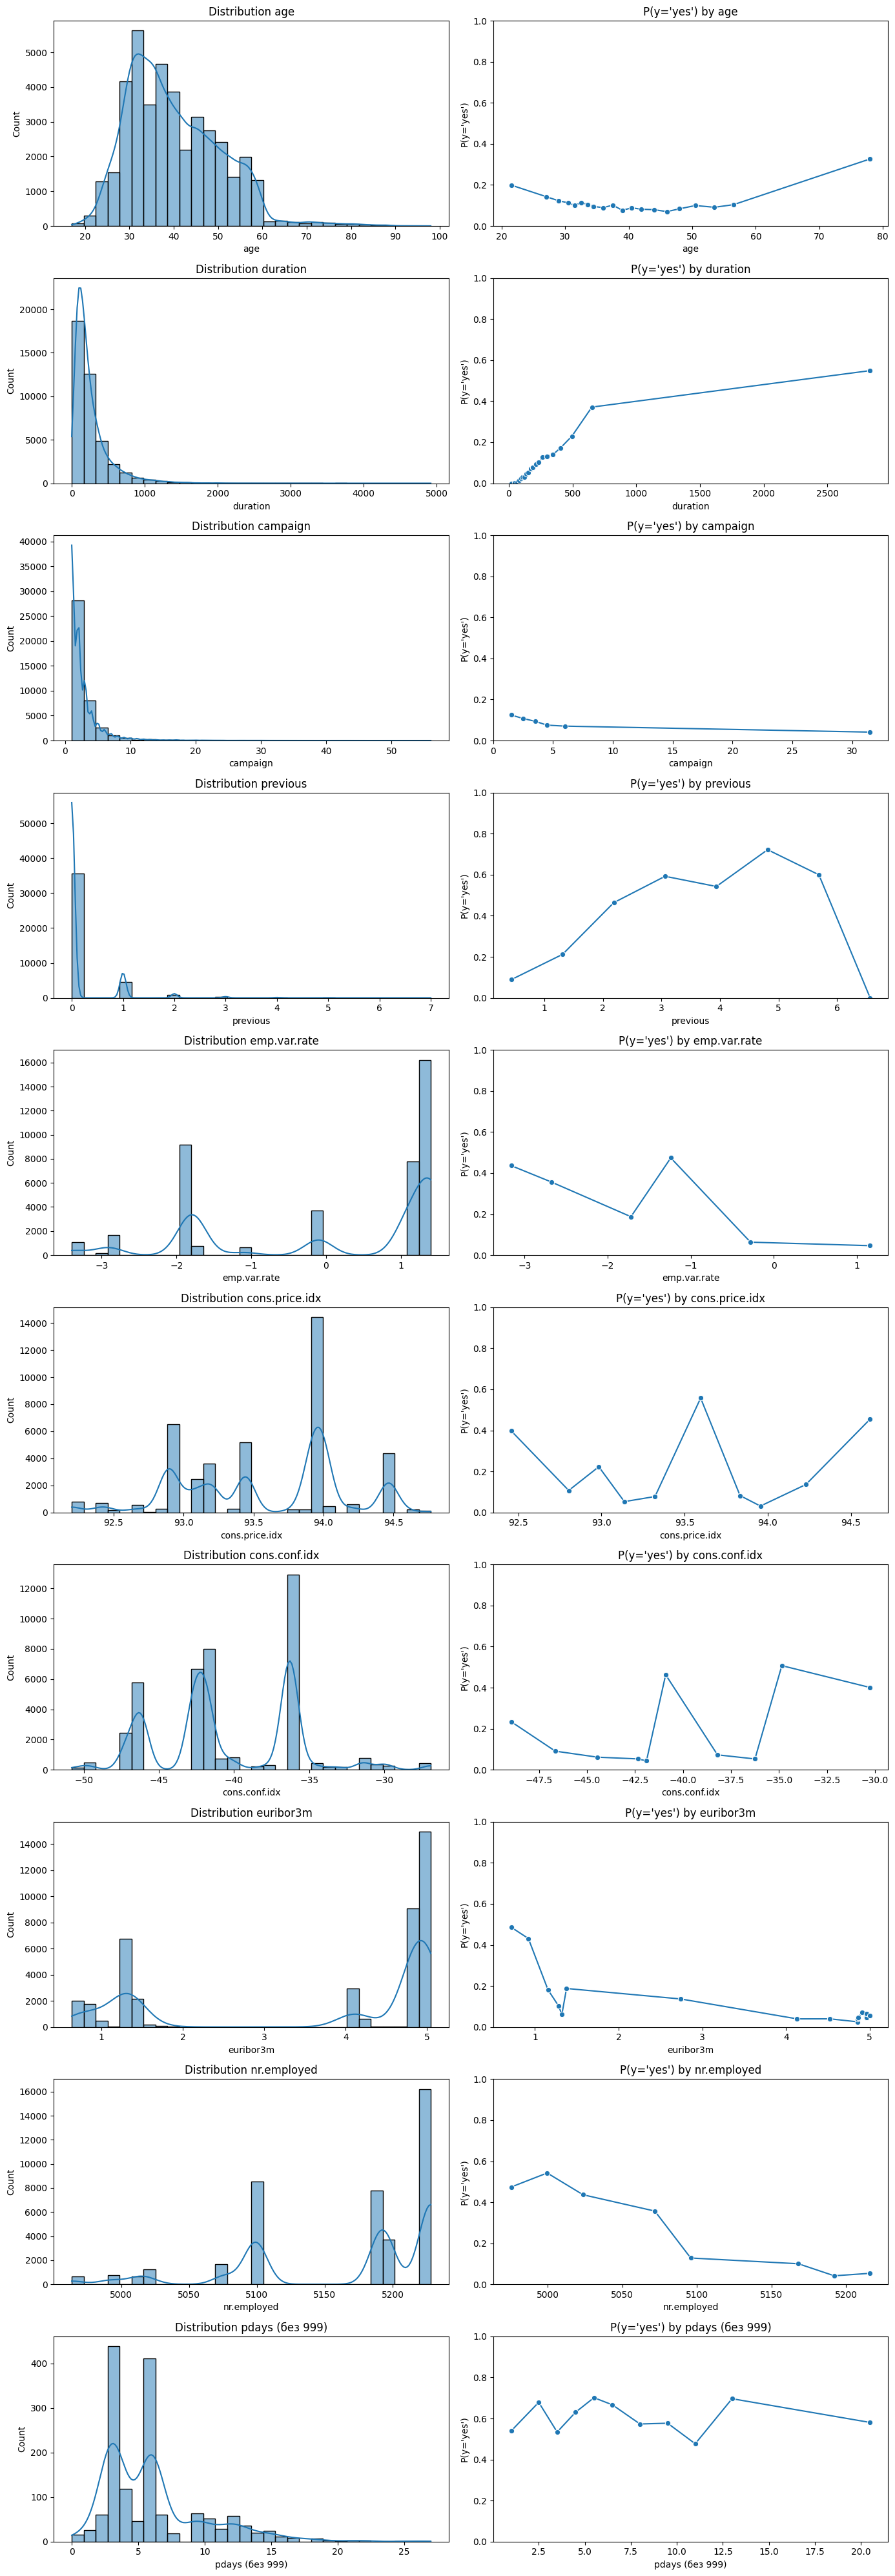

In [ ]:
# Visualize distribution of numeric features + P(y=yes) dependence on value
df_viz = raw_data.copy()

# pdays: 999 means "not contacted before" -> better to replace with NaN for plots
df_viz['pdays_clean'] = df_viz['pdays'].replace(999, np.nan)

# List of numeric features: remove pdays, add pdays_clean
features = [c for c in numeric_cols if c != "pdays"] + ["pdays_clean"]
rename = {"pdays_clean": "pdays (без 999)"}

utils.plot_numeric_block(df_viz, features, target='y', bins=30, rename=rename, q=20)

**Observations**

* Age: a nonlinear relationship is observed between age and the probability of signing a deposit. The probability is lower in the average age range (approximately 30–45 years) and higher among younger and older clients. No linear relationship was found.
* Duration: a strong positive relationship is observed — the longer the call, the higher the probability of signing a contract. However, this indicator is only known after the call is completed, so it cannot be used in the final predictive model.
* campaign: most clients received 1–3 calls. A negative relationship is observed: as the number of contacts within the current campaign increases, the probability of signing a deposit decreases. This may indicate that clients who are called multiple times are less likely to accept the offer.
* previous: for most clients, the value is 0, indicating a predominance of new contacts. At the same time, clients with 1–3 previous contacts show an increased probability of signing a deposit. For larger values, the indicator becomes unstable due to the small number of observations.
* pdays: the analysis was conducted after excluding the value 999 (clients without prior contact). For clients who have already been contacted, no clear relationship is observed between the number of days since the last contact and the target variable.

Macroeconomic variables (emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed) reflect the overall economic state during the marketing campaigns and are the same for client groups within the same time interval.

During the analysis, differences in subscription levels between different economic periods are observed, indicating a potential impact of the macroeconomic context on client behavior. At the same time, these variables have a temporal nature and strong mutual correlation with each other, so the identified relationships should be interpreted as associations rather than direct causal links.

Thus, macroeconomic indicators can provide the model with additional information about the temporal and economic conditions of the campaigns, but require careful interpretation of the results.


====== JOB ======


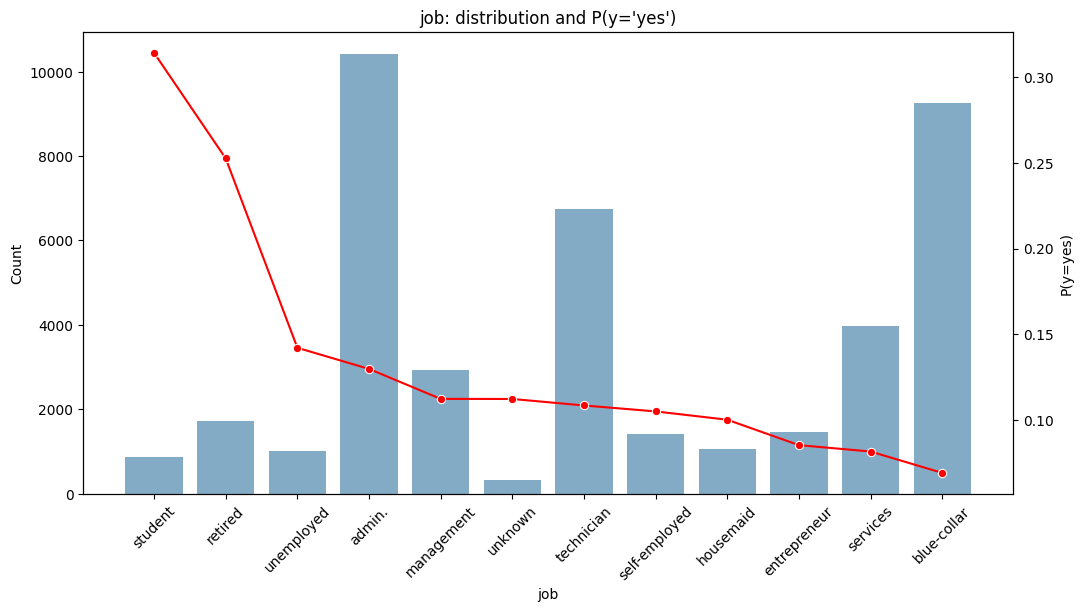


====== MARITAL ======


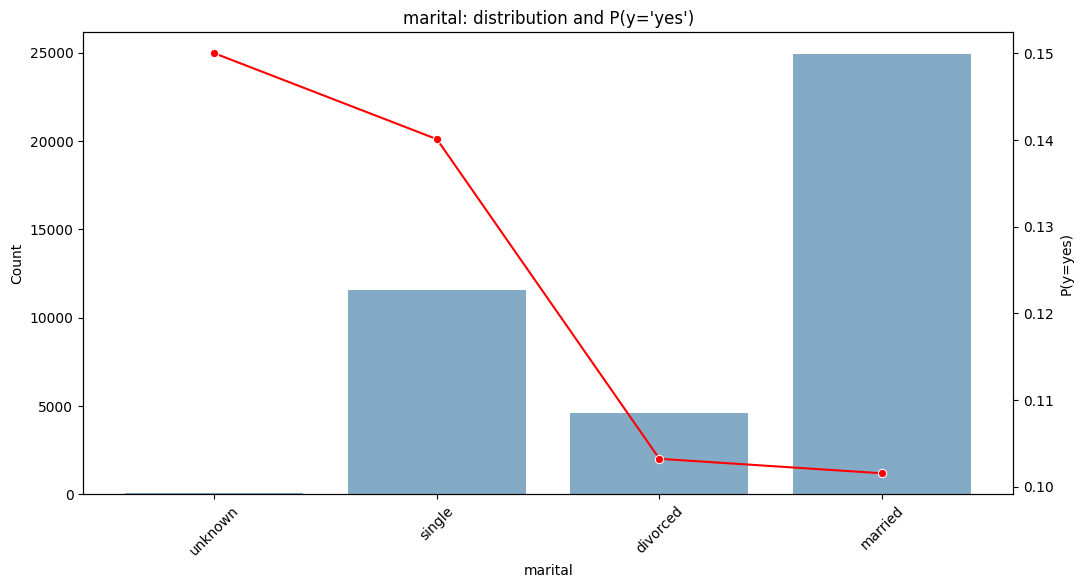


====== EDUCATION ======


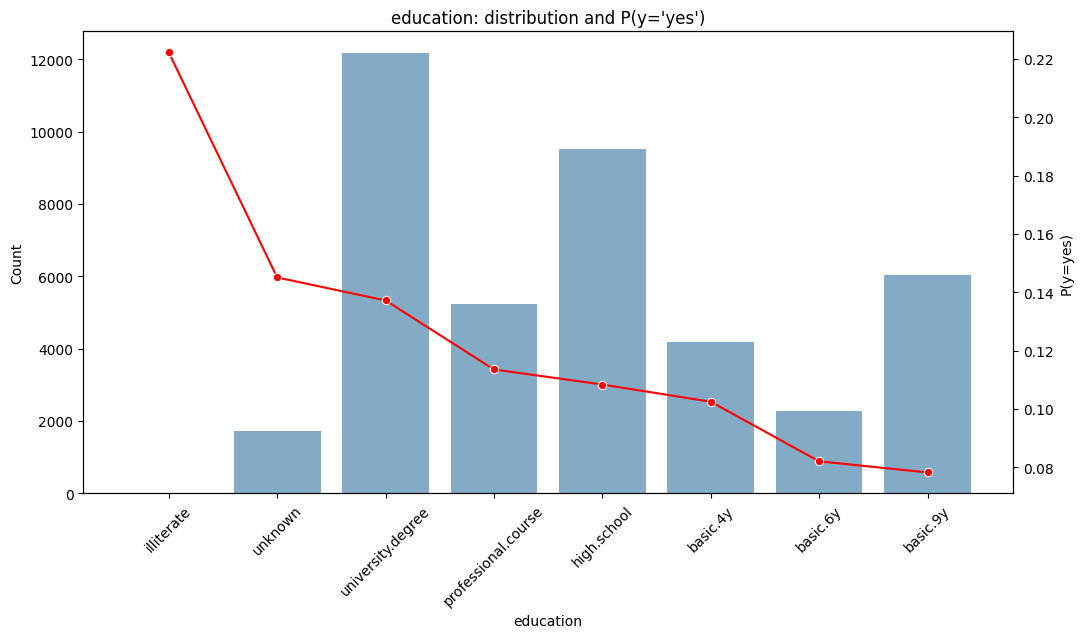


====== DEFAULT ======


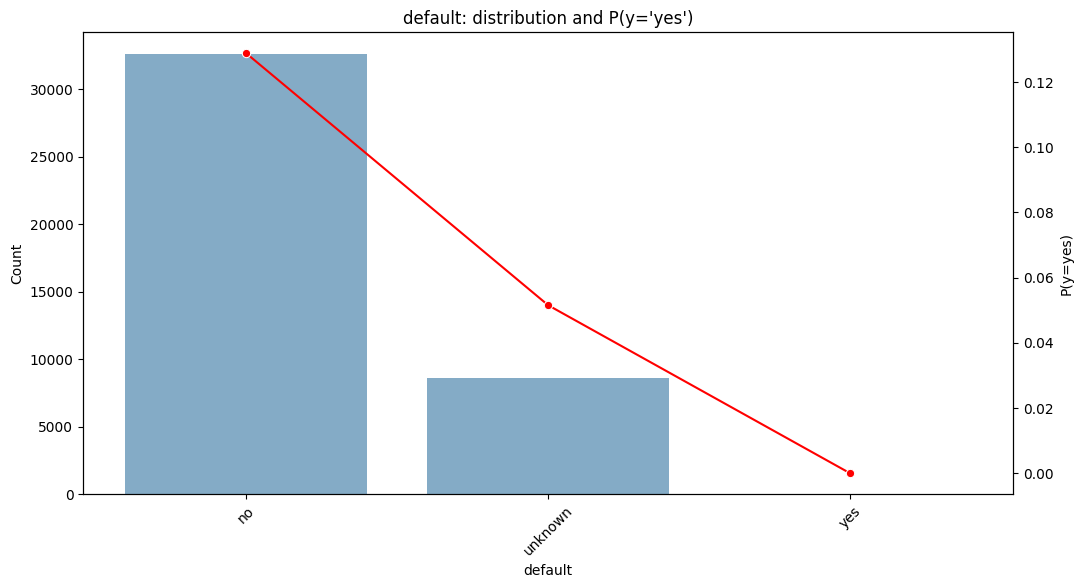


====== HOUSING ======


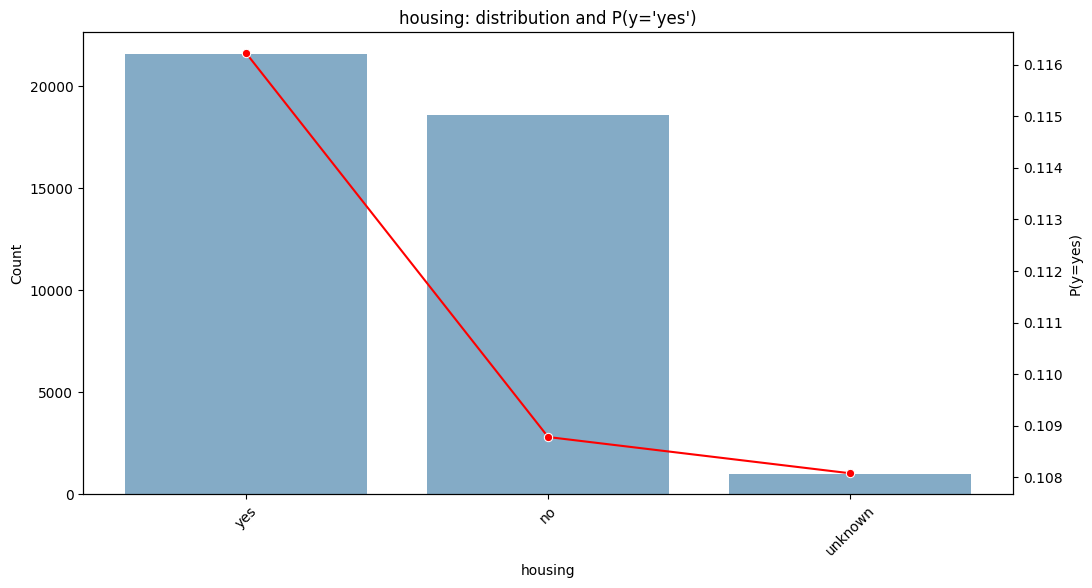


====== LOAN ======


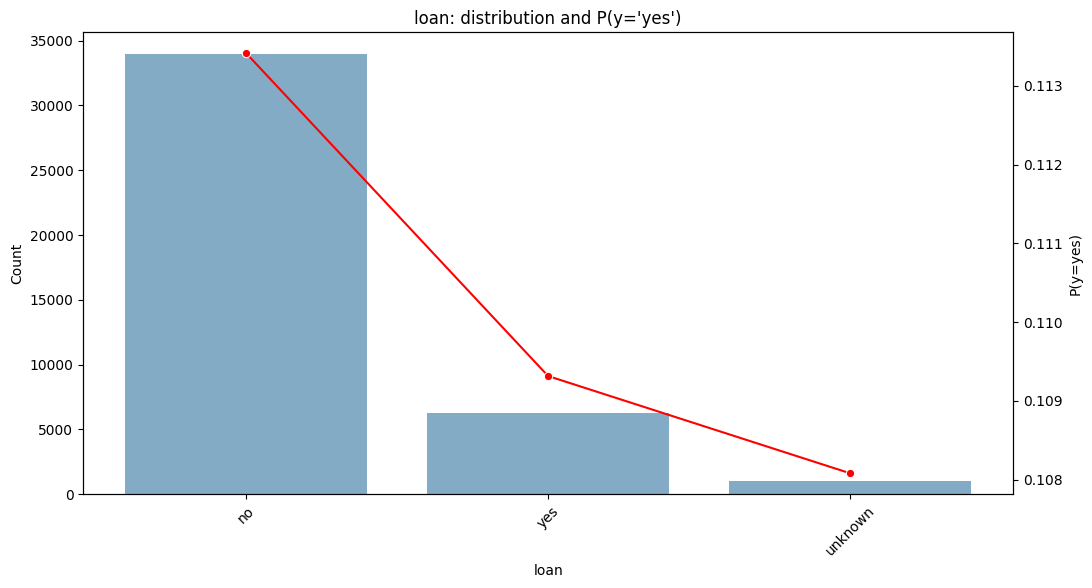


====== CONTACT ======


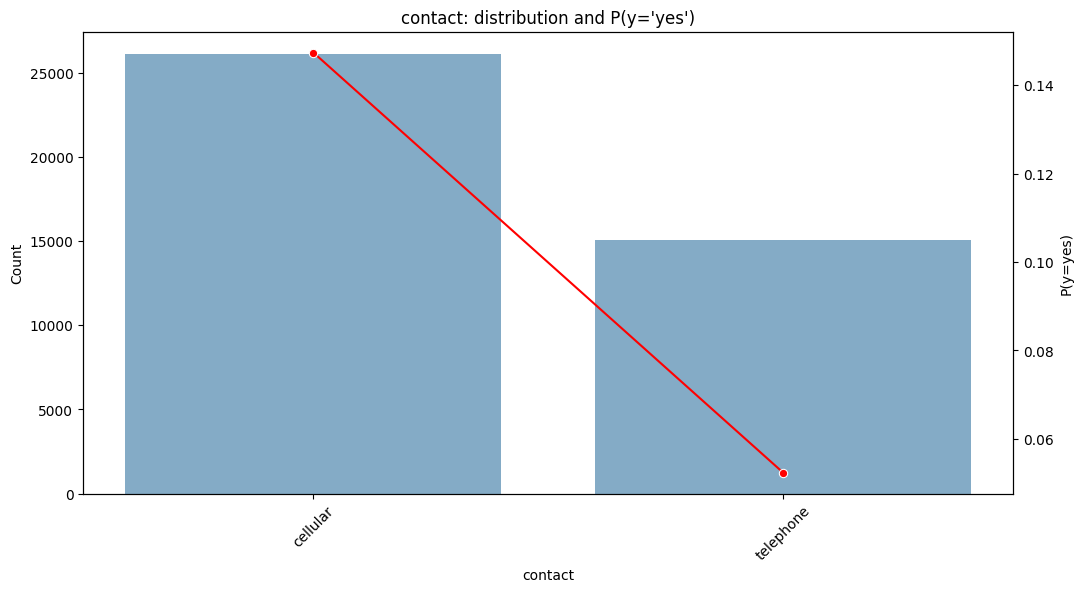


====== MONTH ======


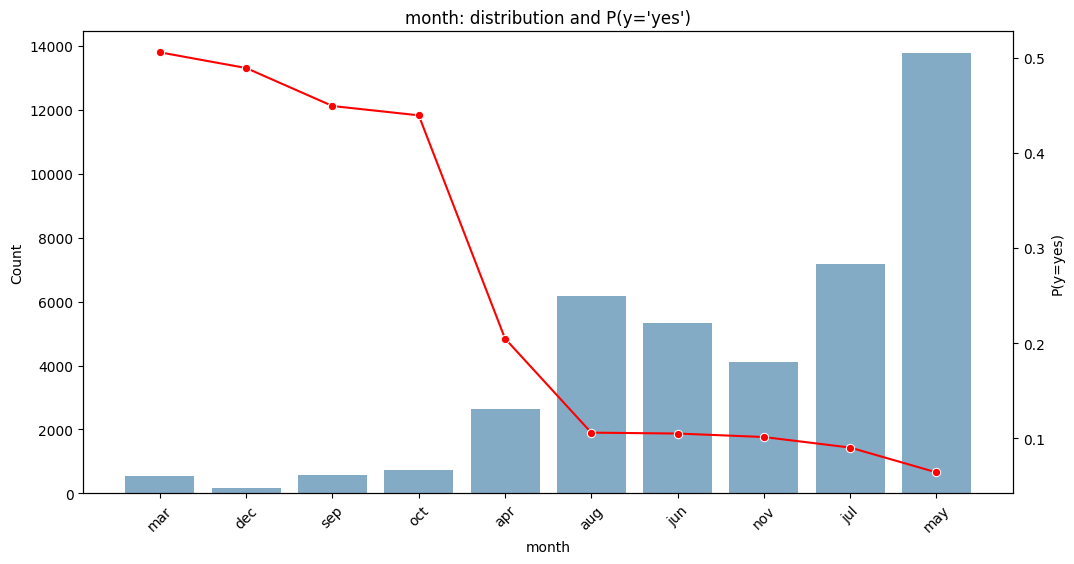


====== DAY_OF_WEEK ======


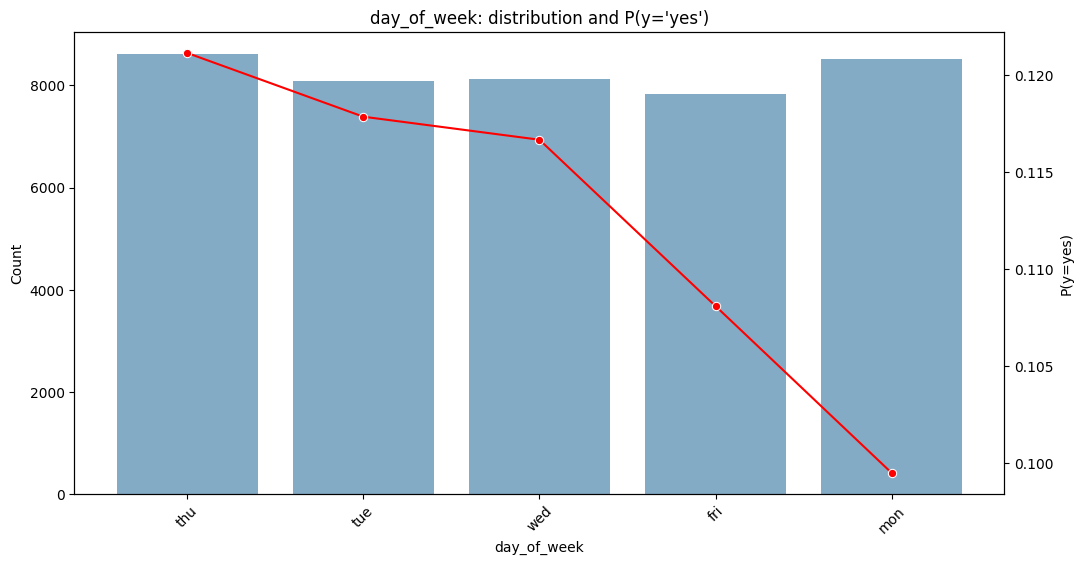


====== POUTCOME ======


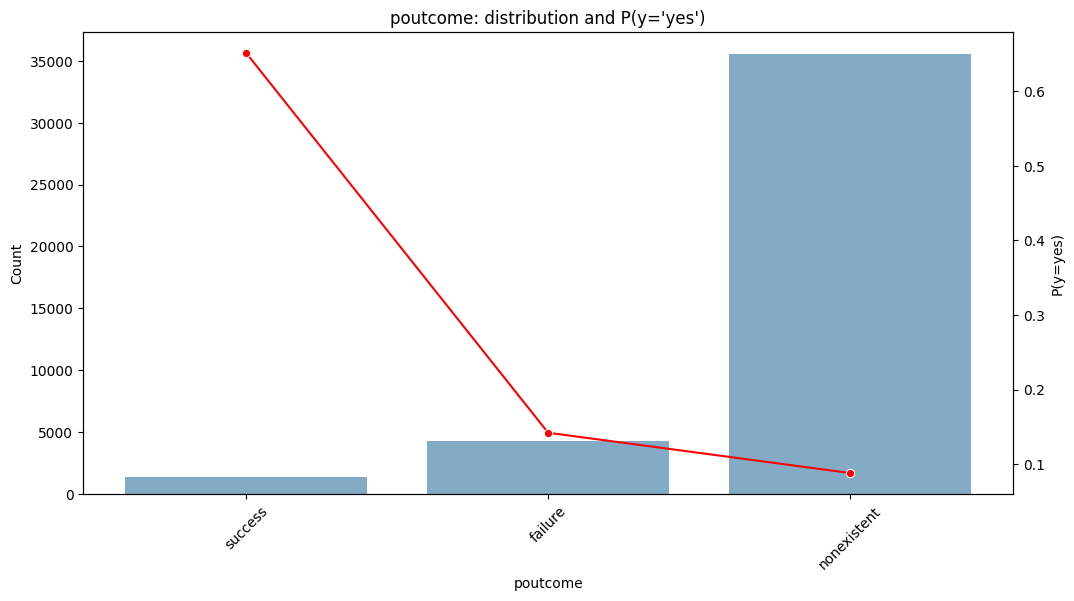

In [ ]:
for col in categorical_cols:
    print(f"\n====== {col.upper()} ======")
    utils.plot_categorical_combined(raw_data, col)

**Observations on Categorical Features**

* job: students and retirees have the highest probability of signing a deposit, while clients with blue-collar professions show the lowest conversion.
* marital: the marital feature shows a weak to moderate influence on the probability of signing a deposit. Clients with single and divorced statuses have a slightly higher conversion compared to married. The difference is a few percentage points and is stable due to a sufficient group size.
* education: clients with higher education have a slightly higher probability of signing a deposit. High values in rare categories (e.g., illiterate) may be statistically unstable.
* default: the presence of credit default is associated with a very low probability of signing a deposit; however, the group of clients with default=yes is small.
* loan, housing: show weak or virtually no influence on the target variable.
* contact: the share of those agreeing to sign a contract is higher among those who were called on mobile phones.
* month: the month feature shows significant variability in subscription levels. In some months, there is a significantly higher conversion with fewer contacts, which may reflect both seasonality and changes in campaign strategies. Calls in December, March, October, and September more frequently led to contract signing.
* day_of_week: does not show a significant influence on the probability of signing a deposit.
* poutcome: clients with a previous successful contact demonstrate a significantly higher probability of signing a deposit.

**General Conclusions**

The most informative features are:

poutcome (previous successful contact significantly increases the likelihood of signing);

month, which reflects seasonality or different campaign strategies;

duration (strong influence, but not used in the final model due to information leakage);

macroeconomic variables (euribor3m, nr.employed, emp.var.rate), which reflect the economic context;

campaign and previous, which characterize the history of contacts with the client.

Job, education, and marital have a moderate impact, while housing, loan, and day_of_week show a weak or minimal connection with the target variable.

**To solve the binary classification problem, it is advisable to use Logistic Regression, kNN, Decision Tree, and Boosting. Due to the presence of class imbalance, the main metric chosen is ROC-AUC, as it allows assessing the model's ability to distinguish between classes regardless of the classification threshold.**

# Data Preprocessing

The pdays feature contains the value 999, which indicates the absence of previous contact with the client. Therefore, the value 999 has been replaced with NaN, and an additional binary variable was_contacted_before has been created to reflect the fact of previous interaction.

In [ ]:
raw_data["was_contacted_before"] = (raw_data["pdays"] != 999).astype(int)
raw_data["pdays"] = raw_data["pdays"].replace(999, np.nan)

In [ ]:
raw_data["pdays"].describe()

,pdays
count,1515.000000
mean,6.014521
std,3.824906
min,0.000000
25%,3.000000
50%,6.000000
75%,7.000000
max,27.000000


In [ ]:
train_df, val_df = train_test_split(raw_data, test_size=0.25, random_state=RANDOM_STATE, stratify=raw_data['y'])

input_cols = train_df.columns.drop(['y', 'duration']).tolist()
target_col = 'y'

train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

In [ ]:
numeric_cols, categorical_cols

(['age',
  'campaign',
  'pdays',
  'previous',
  'emp.var.rate',
  'cons.price.idx',
  'cons.conf.idx',
  'euribor3m',
  'nr.employed',
  'was_contacted_before'],
 ['job',
  'marital',
  'education',
  'default',
  'housing',
  'loan',
  'contact',
  'month',
  'day_of_week',
  'poutcome'])

In [ ]:
# Convert target variables to numerical values (0 and 1)
train_targets_numerical = train_targets.map({'no': 0, 'yes': 1})
val_targets_numerical = val_targets.map({'no': 0, 'yes': 1})

In [ ]:
numeric_pipe_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_pipe_not_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_scaled = ColumnTransformer([
    ("num", numeric_pipe_scaled, numeric_cols),
    ("cat", categorical_pipe, categorical_cols)
])

preprocess_not_scaled = ColumnTransformer([
    ("num", numeric_pipe_not_scaled, numeric_cols),
    ("cat", categorical_pipe, categorical_cols)
])

In [ ]:
SCORING = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "f1": "f1",
    "recall": "recall"
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Baseline Classic Models Training and Cross-Validation

In [ ]:
baseline_pipelines = {
    "Logistic Regression": Pipeline([
        ("preprocess", preprocess_scaled),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),

    "kNN": Pipeline([
        ("preprocess", preprocess_scaled),
        ("model", KNeighborsClassifier())
    ]),

    "Decision Tree": Pipeline([
        ("preprocess", preprocess_not_scaled),
        ("model", DecisionTreeClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ])
}

In [ ]:
baseline_results = []

for model_name, pipeline in baseline_pipelines.items():
    result, fitted_model = utils.evaluate_model_full(
        model_name=model_name,
        estimator=pipeline,
        X_train=train_inputs,
        y_train=train_targets_numerical,
        X_valid=val_inputs,
        y_valid=val_targets_numerical,
        cv=cv,
        scoring=SCORING,
        approach="baseline",
        threshold=0.5
    )

    baseline_results.append(result)


In [ ]:
# converting object types to categorical for XGBoost model
X_train_xgb = train_inputs.copy()
cat_features = X_train_xgb.select_dtypes(include='object').columns
X_train_xgb[cat_features] = train_inputs[cat_features].astype('category')

X_valid_xgb = val_inputs.copy()
X_valid_xgb[cat_features] = X_valid_xgb[cat_features].astype('category')

# ratio of negative class to the positive class
scale_pos_weight = (train_targets_numerical == 0).sum() / (train_targets_numerical == 1).sum()

In [ ]:
xgb_baseline = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    enable_categorical=True,
    missing=np.nan,
    scale_pos_weight=scale_pos_weight
)

In [ ]:
xgb_baseline_result, xgb_baseline_model = utils.evaluate_model_full(
    model_name="XGBoost",
    estimator=xgb_baseline,
    X_train=X_train_xgb,
    y_train=train_targets_numerical,
    X_valid=X_valid_xgb,
    y_valid=val_targets_numerical,
    cv=cv,
    scoring=SCORING,
    approach="baseline",
    threshold=0.5,
    n_jobs=1
)

baseline_results.append(xgb_baseline_result)

In [ ]:
baseline_results_df = pd.DataFrame(baseline_results).sort_values(
    by="valid_roc_auc", ascending=False).reset_index(drop=True)
baseline_results_df

,model,approach,threshold,cv_roc_auc,cv_average_precision,cv_f1,cv_recall,valid_roc_auc,valid_average_precision,valid_f1,valid_recall,params
0,Logistic Regression,baseline,0.5,0.788458,0.446911,0.452343,0.622017,0.802032,0.443574,0.463316,0.639655,"{'C': 1.0, 'class_weight': 'balanced', 'dual':..."
1,XGBoost,baseline,0.5,0.773166,0.426212,0.447924,0.571140,0.790838,0.451555,0.472752,0.609483,"{'objective': 'binary:logistic', 'base_score':..."
2,kNN,baseline,0.5,0.722670,0.317488,0.371364,0.286287,0.739928,0.339067,0.373639,0.281034,"{'algorithm': 'auto', 'leaf_size': 30, 'metric..."
3,Decision Tree,baseline,0.5,0.622882,0.182910,0.325684,0.339469,0.614064,0.176315,0.312158,0.319828,"{'ccp_alpha': 0.0, 'class_weight': 'balanced',..."


**Conclusions on baseline models:**

Basic models were trained using cross-validation: **Logistic Regression, Decision Tree, k-Nearest Neighbors, and XGBoost**. The comparison of models was conducted based on the primary metric **ROC-AUC**, which allows assessing the model's ability to correctly rank objects regardless of the chosen classification threshold.

According to the results of the experiment on the test dataset, **Logistic Regression** showed the best value of **ROC-AUC (0.788)**. The **XGBoost** model demonstrated a very close result **(0.772)**, indicating a similar ability of the models to rank observations. At the same time, **Logistic Regression** has the highest values of **Recall (0.62) and F1-score (0.45)**, which means a better ability of the model to detect positive class objects.

After considering the class imbalance in the **XGBoost** model (using the **scale_pos_weight** parameter), the metrics **Recall and F1-score** improved significantly. The **F1-score for XGBoost (0.45)** became almost the same as for **Logistic Regression**, while **Recall increased to 0.57**, which significantly enhanced the model's ability to find the positive class. This confirms the importance of considering class imbalance when building classification models.

The **kNN** model showed lower results across all key metrics compared to **Logistic Regression and XGBoost**. The **Decision Tree** demonstrated the worst results, which may indicate insufficient generalization ability of this model without hyperparameter tuning.

Thus, the baseline results show that **Logistic Regression and XGBoost demonstrate the best predictive quality on this dataset**. Given the close values of ROC-AUC and the improvement of metrics after considering class imbalance, these models are the most promising candidates for further hyperparameter optimization. In the next stage, model tuning will be conducted to improve their generalization ability and enhance prediction quality.

Additionally, **evaluation on the validation set showed** that the model results remain stable: Logistic Regression achieved ROC-AUC of 0.802, while XGBoost reached 0.791, with F1-score and Recall values also remaining at comparable levels. This confirms the good generalization ability of both models and the absence of significant overfitting.

Therefore, **Logistic Regression and XGBoost have been chosen as the favorite models**, and they will be used in further experiments with hyperparameter tuning.

# Hyperparameter Tuning with RandomizedSearchCV

In [ ]:
# Randomized search for XGBoost
log_reg_dist= {
     "model__C": np.logspace(-3, 2, 20),
     "model__solver": ["liblinear"],
     "model__penalty": ["l1", "l2"],
     "model__class_weight": [None, "balanced"]
 }


In [ ]:
search_results = {}
rand_search_results = []

In [ ]:
model_name = "Logistic Regression"
pipeline = baseline_pipelines[model_name]

log_reg_random_result, log_reg_random_search = utils.evaluate_random_search(
    model_name=model_name,
    estimator=pipeline,
    param_distributions=log_reg_dist,
    X_train=train_inputs,
    y_train=train_targets_numerical,
    X_valid=val_inputs,
    y_valid=val_targets_numerical,
    cv=cv,
    scoring=SCORING,
    n_iter=20,
    threshold=0.5,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rand_search_results.append(log_reg_random_result)
search_results[model_name] = log_reg_random_search

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [ ]:
# Randomized search for XGBoost
xgb_param_dist = {
    "n_estimators": [100, 200, 500],
    "max_depth": [3, 4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "gamma": [0, 0.1, 0.5, 1],
    "min_child_weight": [1, 5, 10]
}

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    tree_method="hist",
    enable_categorical=True,
    missing=np.nan,
    scale_pos_weight=scale_pos_weight
)

In [ ]:
xgb_random_result, xgb_search = utils.evaluate_random_search(
    model_name="XGBoost",
    estimator=xgb_model,
    param_distributions=xgb_param_dist,
    X_train=X_train_xgb,
    y_train=train_targets_numerical,
    X_valid=X_valid_xgb,
    y_valid=val_targets_numerical,
    cv=cv,
    scoring=SCORING,
    n_iter=25,
    threshold=0.5,
    n_jobs=1,
    random_state=RANDOM_STATE
)

rand_search_results.append(xgb_random_result)
search_results["XGBoost"] = xgb_search

Fitting 5 folds for each of 25 candidates, totalling 125 fits


In [ ]:
# threshold tuning for XGBoost
y_valid_proba_xgb = xgb_search.best_estimator_.predict_proba(X_valid_xgb)[:, 1]
best_threshold = utils.get_optimal_threshold(val_targets_numerical, y_valid_proba_xgb)[0]
final_preds_xgb = (y_valid_proba_xgb > best_threshold).astype(int)

rand_search_results.append({
    "model": "XGBoost",
    "approach": "random_search + threshold",
    "threshold": best_threshold,
    "params": xgb_search.best_params_,
    "cv_roc_auc": xgb_random_result["cv_roc_auc"],
    "cv_average_precision": xgb_random_result["cv_average_precision"],
    "cv_f1": xgb_random_result["cv_f1"],
    "cv_recall": xgb_random_result["cv_recall"],
    "valid_roc_auc": roc_auc_score(val_targets_numerical, y_valid_proba_xgb),
    "valid_average_precision": average_precision_score(val_targets_numerical, y_valid_proba_xgb),
    "valid_f1": f1_score(val_targets_numerical, final_preds_xgb),
    "valid_recall": recall_score(val_targets_numerical, final_preds_xgb)
})


In [ ]:
rand_search_results_df = pd.DataFrame(rand_search_results).sort_values(
    by="valid_roc_auc", ascending=False).reset_index(drop=True)

rand_search_results_df

,model,approach,threshold,cv_roc_auc,cv_average_precision,cv_f1,cv_recall,valid_roc_auc,valid_average_precision,valid_f1,valid_recall,params
0,XGBoost,random_search,0.500000,0.797221,0.461103,0.478429,0.607071,0.815164,0.483920,0.492881,0.626724,"{'subsample': 0.9, 'n_estimators': 200, 'min_c..."
1,XGBoost,random_search + threshold,0.646465,0.797221,0.461103,0.478429,0.607071,0.815164,0.483920,0.523625,0.582759,"{'subsample': 0.9, 'n_estimators': 200, 'min_c..."
2,Logistic Regression,random_search,0.500000,0.788983,0.446846,0.449248,0.621442,0.802239,0.446879,0.462779,0.643103,"{'model__solver': 'liblinear', 'model__penalty..."


In [ ]:
importances = xgb_search.best_estimator_.feature_importances_
feature_names = X_train_xgb.columns
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)
feature_importance_df

,feature,importance
18,nr.employed,0.583118
14,emp.var.rate,0.083569
16,cons.conf.idx,0.057931
8,month,0.045851
19,was_contacted_before,0.041562
7,contact,0.029102
11,pdays,0.027288
17,euribor3m,0.025977
4,default,0.018745
13,poutcome,0.014727


In [ ]:
# deleting non-important features
low_importance_features = feature_importance_df[feature_importance_df['importance'] < 0.01]['feature'].tolist()
X_train_xgb_reduced = X_train_xgb.drop(columns=low_importance_features)
X_valid_xgb_reduced = X_valid_xgb.drop(columns=low_importance_features)


In [ ]:
final_xgb_reduced = XGBClassifier(
    **xgb_search.best_params_,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    tree_method="hist",
    enable_categorical=True,
    missing=np.nan,
    scale_pos_weight=scale_pos_weight
)

reduced_result, final_xgb_reduced_model = utils.evaluate_model_full(
    model_name="XGBoost",
    estimator=final_xgb_reduced,
    X_train=X_train_xgb_reduced,
    y_train=train_targets_numerical,
    X_valid=X_valid_xgb_reduced,
    y_valid=val_targets_numerical,
    cv=cv,
    scoring=SCORING,
    approach="random_search + reduced_features",
    threshold=0.5,
    n_jobs=1
)

rand_search_results.append(reduced_result)

In [ ]:
rand_search_results_df = pd.DataFrame(rand_search_results).sort_values(
    by="valid_roc_auc", ascending=False)

rand_search_results_df

,model,approach,threshold,cv_roc_auc,cv_average_precision,cv_f1,cv_recall,valid_roc_auc,valid_average_precision,valid_f1,valid_recall,params
1,XGBoost,random_search,0.500000,0.797221,0.461103,0.478429,0.607071,0.815164,0.483920,0.492881,0.626724,"{'subsample': 0.9, 'n_estimators': 200, 'min_c..."
2,XGBoost,random_search + threshold,0.646465,0.797221,0.461103,0.478429,0.607071,0.815164,0.483920,0.523625,0.582759,"{'subsample': 0.9, 'n_estimators': 200, 'min_c..."
3,XGBoost,random_search + reduced_features,0.500000,0.798611,0.457616,0.472116,0.618568,0.812541,0.471758,0.475279,0.642241,"{'objective': 'binary:logistic', 'base_score':..."
0,Logistic Regression,random_search,0.500000,0.788983,0.446846,0.449248,0.621442,0.802239,0.446879,0.462779,0.643103,"{'model__solver': 'liblinear', 'model__penalty..."


**Results of RandomizedResearchCV models:**
* **Comparison of algorithms:** During RandomizedSearchCV, **XGBoost** showed the best results (**Valid ROC-AUC~0.816**). However, logistic regression showed a not much worse result (**Valid ROC-AUC~0.802**), indicating the presence of strong linear dependencies.

* **Metric analysis:** Optimizing the classification threshold for XGBoost allowed for an increase in **F1 Score from 0.49 to 0.52**. This improved the accuracy of predictions (Precision), but led to a decrease in **Recall (from 0.63 to 0.58)**. Such a compromise is acceptable if the priority is the quality of contacts rather than their quantity. If the goal is to reach as many potential clients as possible, it is better to keep the standard threshold, as at 0.65 we lose about 5% Recall (from 0.63 to 0.58).

* **Feature importance:** Macroeconomic indicators contribute the most to the predictions (especially **nr.employed** - more than **55% importance**). It was surprising that individual characteristics (age, education, marital status) have a weight of less than 1% and are essentially noise for the model. This indicates that in this sample, economic trends are so dominant that they overshadow the differences in behavior between different social groups.

* **Data optimization:** Removing insignificant features (below 1% importance) proved to be extremely effective. The simplified model not only maintained overall quality (ROC-AUC) but also demonstrated the **highest recall rate (Recall ~0.64)** among all tested models. This means that such a model is best suited for tasks where it is critically important to find the maximum number of potential clients. Additionally, the increase in **CV ROC-AUC to 0.80** confirms the higher stability of the model on new data.

# Hyperopt tuning for XGBoost

In [ ]:
def objective(params):
  dtrain = xgb.DMatrix(X_train_xgb_reduced, label=train_targets_numerical, enable_categorical=True)

  cv_params = {
        'objective': 'binary:logistic',
        'learning_rate': params['learning_rate'],
        'max_depth': int(params['max_depth']),
        'min_child_weight': params['min_child_weight'],
        'subsample': params['subsample'],
        'colsample_bytree': params['colsample_bytree'],
        'gamma': params['gamma'],
        'alpha': params['reg_alpha'],
        'lambda': params['reg_lambda'],
        'scale_pos_weight': scale_pos_weight,
        'random_state': RANDOM_STATE,
        'eval_metric': 'auc'
    }

  cv_results = xgb.cv(
        params=cv_params,
        dtrain=dtrain,
        num_boost_round=int(params['n_estimators']),
        nfold=5,
        early_stopping_rounds=10,
        metrics='auc',
        stratified=True,
        seed=RANDOM_STATE
    )

  best_auc = cv_results['test-auc-mean'].max()
  best_iteration = len(cv_results)

  return {
      'loss': -best_auc,
      'status': STATUS_OK,
      'best_n_estimators':best_iteration}


# Простір гіперпараметрів
space = {
    'n_estimators': 1000,
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
    'max_depth': hp.quniform('max_depth', 3, 10, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 15, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'gamma': hp.uniform('gamma', 0.0, 0.5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 5.0),
    'reg_lambda': hp.uniform('reg_lambda', 0, 5.0),
    'scale_pos_weight': scale_pos_weight
}

# Оптимізація
trials = Trials()
best_params = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=100,
    trials=trials,
    rstate=np.random.default_rng(RANDOM_STATE))

best_n_tree = trials.best_trial['result']['best_n_estimators']


print(f"Selected number of trees: {best_n_tree}")
print(f"Best hyperparameters: {best_params}")

final_xgb_hyperopt = XGBClassifier(
    n_estimators=int(best_n_tree),
    learning_rate=best_params['learning_rate'],
    max_depth=int(best_params['max_depth']),
    min_child_weight=int(best_params['min_child_weight']),
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    gamma=best_params['gamma'],
    reg_alpha=best_params['reg_alpha'],
    reg_lambda=best_params['reg_lambda'],
    scale_pos_weight=scale_pos_weight,
    enable_categorical=True,
    missing=np.nan,
    random_state=RANDOM_STATE
)

hyperopt_results = []
hyperopt_result, final_xgb_hyperopt_model = utils.evaluate_model_full(
    model_name="XGBoost",
    estimator=final_xgb_hyperopt,
    X_train=X_train_xgb_reduced,
    y_train=train_targets_numerical,
    X_valid=X_valid_xgb_reduced,
    y_valid=val_targets_numerical,
    cv=cv,
    scoring=SCORING,
    approach="hyperopt + reduced_features",
    threshold=0.5,
    n_jobs=1
)

hyperopt_results.append(hyperopt_result)

100%|██████████| 100/100 [03:29<00:00,  2.10s/trial, best loss: -0.800796656246099]
Selected number of trees: 23
Best hyperparameters: {'colsample_bytree': np.float64(0.7384568419077001), 'gamma': np.float64(0.33681966941924346), 'learning_rate': np.float64(0.1356859780781223), 'max_depth': np.float64(8.0), 'min_child_weight': np.float64(3.0), 'reg_alpha': np.float64(1.908481266580202), 'reg_lambda': np.float64(4.214492805892626), 'subsample': np.float64(0.5360742926110122)}


In [ ]:
hyperopt_results_df = pd.DataFrame(hyperopt_results).sort_values(
    by="valid_roc_auc", ascending=False)

hyperopt_results_df

,model,approach,threshold,cv_roc_auc,cv_average_precision,cv_f1,cv_recall,valid_roc_auc,valid_average_precision,valid_f1,valid_recall,params
0,XGBoost,hyperopt + reduced_features,0.5,0.797899,0.459504,0.463243,0.631212,0.811922,0.473162,0.47477,0.644828,"{'objective': 'binary:logistic', 'base_score':..."


In [ ]:
# threshold tuning for XGBoost
y_hp_proba = final_xgb_hyperopt_model.predict_proba(X_valid_xgb_reduced)[:, 1]

best_threshold_hp = utils.get_optimal_threshold(
    val_targets_numerical,
    y_hp_proba
)[0]

final_preds_hp = (y_hp_proba >= best_threshold_hp).astype(int)

hyperopt_results.append({
    "model": "XGBoost",
    "approach": "hyperopt + reduced_features + threshold",
    "threshold": best_threshold_hp,
    "params": {
        "best_params": {
            **best_params,
            "max_depth": int(best_params["max_depth"]),
            "min_child_weight": int(best_params["min_child_weight"]),
            "n_estimators": int(best_n_tree)
        }
    },
    "cv_roc_auc": hyperopt_result["cv_roc_auc"],
    "cv_average_precision": hyperopt_result["cv_average_precision"],
    "cv_f1": hyperopt_result["cv_f1"],
    "cv_recall": hyperopt_result["cv_recall"],
    "valid_roc_auc": roc_auc_score(val_targets_numerical, y_hp_proba),
    "valid_average_precision": average_precision_score(val_targets_numerical, y_hp_proba),
    "valid_f1": f1_score(val_targets_numerical, final_preds_hp),
    "valid_recall": recall_score(val_targets_numerical, final_preds_hp)
})

In [ ]:
hyperopt_results_df = pd.DataFrame(hyperopt_results).sort_values(
    by="valid_roc_auc", ascending=False)

hyperopt_results_df

,model,approach,threshold,cv_roc_auc,cv_average_precision,cv_f1,cv_recall,valid_roc_auc,valid_average_precision,valid_f1,valid_recall,params
0,XGBoost,hyperopt + reduced_features,0.500000,0.797899,0.459504,0.463243,0.631212,0.811922,0.473162,0.474770,0.644828,"{'objective': 'binary:logistic', 'base_score':..."
1,XGBoost,hyperopt + reduced_features + threshold,0.636364,0.797899,0.459504,0.463243,0.631212,0.811922,0.473162,0.520486,0.591379,{'best_params': {'colsample_bytree': 0.7384568...


In [ ]:
rand_search_results_df

,model,approach,threshold,cv_roc_auc,cv_average_precision,cv_f1,cv_recall,valid_roc_auc,valid_average_precision,valid_f1,valid_recall,params
1,XGBoost,random_search,0.500000,0.797221,0.461103,0.478429,0.607071,0.815164,0.483920,0.492881,0.626724,"{'subsample': 0.9, 'n_estimators': 200, 'min_c..."
2,XGBoost,random_search + threshold,0.646465,0.797221,0.461103,0.478429,0.607071,0.815164,0.483920,0.523625,0.582759,"{'subsample': 0.9, 'n_estimators': 200, 'min_c..."
3,XGBoost,random_search + reduced_features,0.500000,0.798611,0.457616,0.472116,0.618568,0.812541,0.471758,0.475279,0.642241,"{'objective': 'binary:logistic', 'base_score':..."
0,Logistic Regression,random_search,0.500000,0.788983,0.446846,0.449248,0.621442,0.802239,0.446879,0.462779,0.643103,"{'model__solver': 'liblinear', 'model__penalty..."


**Conclusions on Hyperopt Tuning of the XGBoost Model**

* As a result of hyperparameter tuning using **Hyperopt**, the XGBoost model on data after removing insignificant features demonstrated better generalization ability, reflected in a higher **Average Precision (0.473)** compared to the previous stage (RandomSearch).

* Thanks to the combination of Hyperopt and the **Reduced Features** strategy (removing features with importance < 1%), the highest recall rate among all experiments was achieved - **Recall 0.644**. This means that the model identifies over 64% of all potentially successful cases, which is a critically important metric for marketing campaigns with broad reach.

* Experiments with the threshold in Hyperopt confirmed the model's flexibility:

  * **Base threshold (0.50)**: Provides maximum audience coverage (Recall 0.64).

  * **Optimized threshold (0.636)**: Increases **F1-score to 0.52**. Although this leads to a slight decrease in Recall, the model's precision significantly increases. This allows for recommending this threshold for campaigns where the priority is on the "quality" of contacts and minimizing spam for customers.

* The minimal gap between metrics on cross-validation and the final validation set (cv_roc_auc 0.797 vs valid_roc_auc 0.811) confirms the high stability of the selected hyperparameters. The model is ready for use on new, "unseen" data.

# Feature importance analysis with SHAP

In [ ]:
explainer = shap.TreeExplainer(final_xgb_hyperopt_model)
shap_values = explainer.shap_values(X_train_xgb_reduced)

shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], X_train_xgb_reduced.iloc[0, :])

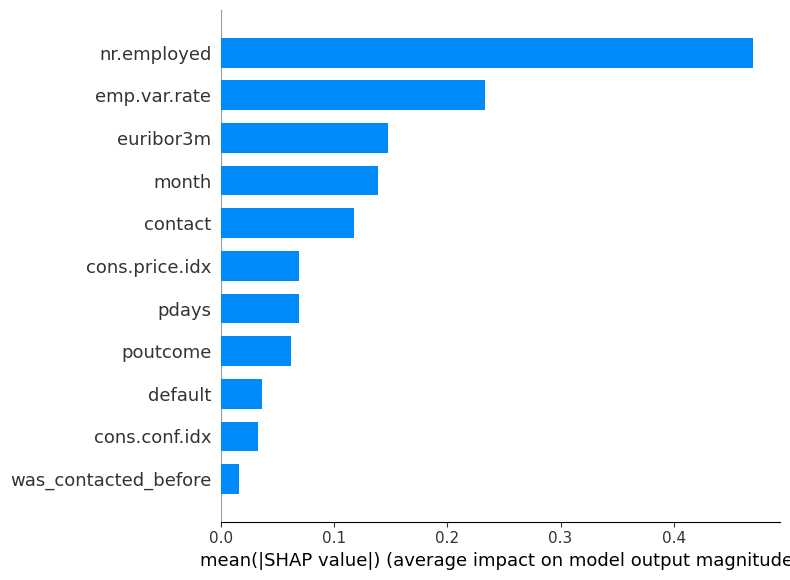

In [ ]:
shap.summary_plot(shap_values, X_train_xgb_reduced, plot_type="bar")

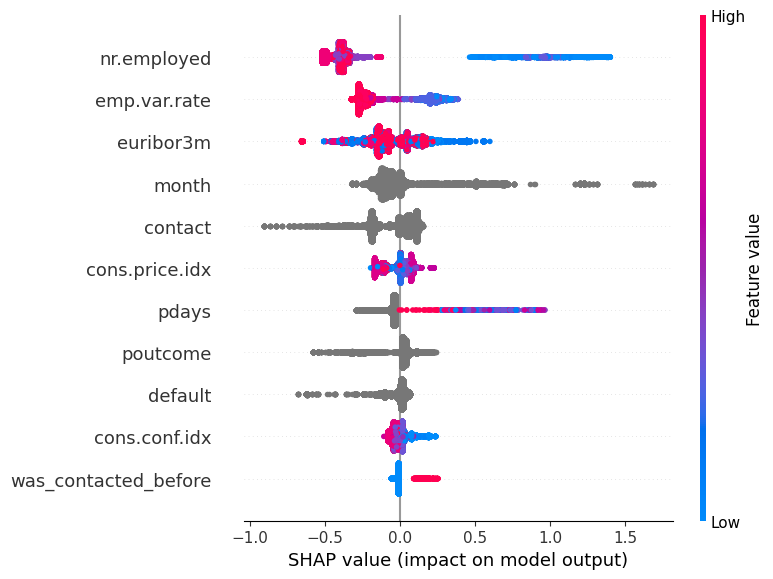

In [ ]:
shap.summary_plot(shap_values, X_train_xgb_reduced,)

According to the SHAP analysis, the most influential feature for the model is `nr.employed`, which significantly determines the prediction outcome. 
Also, `emp.var.rate`, `euribor3m`, `month`, and `contact` make a significant contribution. 
Other features, such as `cons.price.idx`, `pdays`, and `poutcome`, have a moderate impact, while the remaining factors have a negligible effect. 
Overall, the model relies primarily on a small number of key economic and contact characteristics.

# Best Model Error Analysis and Potential Improvements

In [ ]:
y_pred = final_xgb_hyperopt_model.predict(X_valid_xgb_reduced)
y_proba  = final_xgb_hyperopt_model.predict_proba(X_valid_xgb_reduced)[:, 1]

error_analysis_df = X_valid_xgb_reduced.copy().reset_index(drop=True)
error_analysis_df["actual"] = val_targets_numerical.reset_index(drop=True)
error_analysis_df["predicted"] = y_pred
error_analysis_df["proba"] = y_proba

error_analysis_df["prediction_type"] = (
    error_analysis_df["actual"].astype(str) + "_" +
    error_analysis_df["predicted"].astype(str)
).map({
    "1_1": "TP",
    "0_0": "TN",
    "0_1": "FP",
    "1_0": "FN"
})

print("Prediction type distribution:")
display(error_analysis_df["prediction_type"].value_counts())

fp_df = error_analysis_df[error_analysis_df["prediction_type"] == "FP"].copy()
fn_df = error_analysis_df[error_analysis_df["prediction_type"] == "FN"].copy()
tp_df = error_analysis_df[error_analysis_df["prediction_type"] == "TP"].copy()
tn_df = error_analysis_df[error_analysis_df["prediction_type"] == "TN"].copy()


Prediction type distribution:


,count
prediction_type,
TN,7891
FP,1243
TP,748
FN,412


In [ ]:
# Numeric features: FN vs TP
numeric_cols = X_valid_xgb_reduced.select_dtypes(include="number").columns.tolist()

fn_vs_tp_mean = pd.DataFrame({
    "TP_mean": tp_df[numeric_cols].mean(),
    "FN_mean": fn_df[numeric_cols].mean()
})

fn_vs_tp_mean["difference"] = fn_vs_tp_mean["FN_mean"] - fn_vs_tp_mean["TP_mean"]
fn_vs_tp_mean["abs_difference"] = fn_vs_tp_mean["difference"].abs()

print("Top numeric differences between FN and TP (mean values):")
display(
    fn_vs_tp_mean
    .sort_values("abs_difference", ascending=False)
    .head(10)
)

Top numeric differences between FN and TP (mean values):


,TP_mean,FN_mean,difference,abs_difference
nr.employed,5044.350401,5181.657767,137.307366,137.307366
cons.conf.idx,-38.725802,-41.608495,-2.882693,2.882693
euribor3m,1.085190,3.812029,2.726839,2.726839
emp.var.rate,-2.209225,0.316019,2.525244,2.525244
cons.price.idx,93.181579,93.584867,0.403288,0.403288
was_contacted_before,0.308824,0.000000,-0.308824,0.308824
pdays,5.757576,NaN,NaN,NaN


In [ ]:
# Numeric features: FP vs TN
fp_vs_tn_mean = pd.DataFrame({
    "TN_mean": tn_df[numeric_cols].mean(),
    "FP_mean": fp_df[numeric_cols].mean()
})

fp_vs_tn_mean["difference"] = fp_vs_tn_mean["FP_mean"] - fp_vs_tn_mean["TN_mean"]
fp_vs_tn_mean["abs_difference"] = fp_vs_tn_mean["difference"].abs()

print("Top numeric differences between FP and TN (mean values):")
display(
    fp_vs_tn_mean
    .sort_values("abs_difference", ascending=False)
    .head(10)
)

Top numeric differences between FP and TN (mean values):


,TN_mean,FP_mean,difference,abs_difference
nr.employed,5194.188734,5068.161947,-126.026787,126.026787
euribor3m,4.243909,1.242815,-3.001094,3.001094
emp.var.rate,0.643264,-2.133709,-2.776973,2.776973
pdays,6.777778,5.600000,-1.177778,1.177778
cons.price.idx,93.700386,93.035755,-0.664632,0.664632
cons.conf.idx,-40.537625,-40.929284,-0.391659,0.391659
was_contacted_before,0.001141,0.108608,0.107468,0.107468


In [ ]:
# Categorical features analysis
selected_categorical_cols = [
    col for col in ["contact", "month", "poutcome"]
    if col in X_valid_xgb_reduced.columns
]

print("Categorical columns used:")
print(selected_categorical_cols)

Categorical columns used:
['contact', 'month', 'poutcome']


In [ ]:
for col in selected_categorical_cols:
    print(f"\nDistribution of '{col}' for TP vs FN:")

    display(
        error_analysis_df[error_analysis_df["prediction_type"].isin(["TP", "FN"])]
        .groupby("prediction_type")[col]
        .value_counts(normalize=True)
        .rename("share")
        .reset_index()
    )


Distribution of 'contact' for TP vs FN:


,prediction_type,contact,share
0,FN,cellular,0.699029
1,FN,telephone,0.300971
2,TP,cellular,0.898396
3,TP,telephone,0.101604



Distribution of 'month' for TP vs FN:


,prediction_type,month,share
0,FN,may,0.385922
1,FN,jul,0.228155
2,FN,aug,0.157767
3,FN,jun,0.114078
4,FN,nov,0.080097
5,FN,apr,0.031553
6,FN,sep,0.002427
7,FN,dec,0.000000
8,FN,mar,0.000000
9,FN,oct,0.000000



Distribution of 'poutcome' for TP vs FN:


,prediction_type,poutcome,share
0,FN,nonexistent,0.898058
1,FN,failure,0.101942
2,FN,success,0.000000
3,TP,nonexistent,0.550802
4,TP,success,0.286096
5,TP,failure,0.163102


In [ ]:
for col in selected_categorical_cols:
    print(f"\nDistribution of '{col}' for TN vs FP:")

    display(
        error_analysis_df[error_analysis_df["prediction_type"].isin(["TN", "FP"])]
        .groupby("prediction_type")[col]
        .value_counts(normalize=True)
        .rename("share")
        .reset_index()
    )


Distribution of 'contact' for TN vs FP:


,prediction_type,contact,share
0,FP,cellular,0.861625
1,FP,telephone,0.138375
2,TN,cellular,0.564187
3,TN,telephone,0.435813



Distribution of 'month' for TN vs FP:


,prediction_type,month,share
0,FP,apr,0.296862
1,FP,may,0.155270
2,FP,aug,0.108608
3,FP,jun,0.107804
4,FP,nov,0.081255
5,FP,oct,0.079646
6,FP,mar,0.050684
7,FP,sep,0.050684
8,FP,jul,0.049075
9,FP,dec,0.020113



Distribution of 'poutcome' for TN vs FP:


,prediction_type,poutcome,share
0,FP,nonexistent,0.725664
1,FP,failure,0.178600
2,FP,success,0.095736
3,TN,nonexistent,0.916234
4,TN,failure,0.082753
5,TN,success,0.001014


In [ ]:
# Most confident errors
print("Most confident False Positives:")
display(fp_df.sort_values("proba", ascending=False).head(5))

print("Most confident False Negatives:")
display(fn_df.sort_values("proba", ascending=True).head(5))

Most confident False Positives:


,default,contact,month,pdays,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,was_contacted_before,actual,predicted,proba,prediction_type
6160,no,cellular,mar,7.0,success,-1.8,93.369,-34.8,0.653,5008.7,1,0,1,0.945242,FP
10123,no,cellular,sep,6.0,success,-1.1,94.199,-37.5,0.879,4963.6,1,0,1,0.943421,FP
5057,no,cellular,sep,6.0,success,-1.1,94.199,-37.5,0.877,4963.6,1,0,1,0.943421,FP
2850,no,cellular,sep,6.0,success,-1.1,94.199,-37.5,0.882,4963.6,1,0,1,0.943421,FP
10007,no,cellular,jul,3.0,success,-1.7,94.215,-40.3,0.797,4991.6,1,0,1,0.943063,FP


Most confident False Negatives:


,default,contact,month,pdays,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,was_contacted_before,actual,predicted,proba,prediction_type
176,no,telephone,jul,NaN,nonexistent,1.4,93.918,-42.7,4.968,5228.1,0,1,0,0.146081,FN
3866,no,telephone,jul,NaN,nonexistent,1.4,93.918,-42.7,4.966,5228.1,0,1,0,0.157977,FN
1098,no,telephone,may,NaN,nonexistent,1.1,93.994,-36.4,4.855,5191.0,0,1,0,0.175810,FN
1689,no,telephone,may,NaN,nonexistent,1.1,93.994,-36.4,4.855,5191.0,0,1,0,0.175810,FN
10015,no,telephone,may,NaN,nonexistent,1.1,93.994,-36.4,4.855,5191.0,0,1,0,0.175810,FN


The error analysis showed that the model better recognizes the negative class, which is partly due to data imbalance; however, it allows for a significant number of false positive predictions. At the same time, the errors have a systematic nature: FN occurs more frequently for clients without previous contacts (poutcome = nonexistent) and with telephone, while FP occurs for clients with characteristics similar to the positive class (for example, cellular and the presence of previous contacts).

This indicates that the model does not fully distinguish between groups of clients that are similar in characteristics, so its quality can be improved through additional feature engineering, better handling of categorical features, and optimization of the classification threshold.

# Final Conclusions and Model Comparison Table

In [ ]:
all_experiments_df = pd.concat([
    baseline_results_df,
    rand_search_results_df,
    hyperopt_results_df
], ignore_index=True)

all_experiments_df

,model,approach,threshold,cv_roc_auc,cv_average_precision,cv_f1,cv_recall,valid_roc_auc,valid_average_precision,valid_f1,valid_recall,params
0,Logistic Regression,baseline,0.500000,0.788458,0.446911,0.452343,0.622017,0.802032,0.443574,0.463316,0.639655,"{'C': 1.0, 'class_weight': 'balanced', 'dual':..."
1,XGBoost,baseline,0.500000,0.773166,0.426212,0.447924,0.571140,0.790838,0.451555,0.472752,0.609483,"{'objective': 'binary:logistic', 'base_score':..."
2,kNN,baseline,0.500000,0.722670,0.317488,0.371364,0.286287,0.739928,0.339067,0.373639,0.281034,"{'algorithm': 'auto', 'leaf_size': 30, 'metric..."
3,Decision Tree,baseline,0.500000,0.622882,0.182910,0.325684,0.339469,0.614064,0.176315,0.312158,0.319828,"{'ccp_alpha': 0.0, 'class_weight': 'balanced',..."
4,XGBoost,random_search,0.500000,0.797221,0.461103,0.478429,0.607071,0.815164,0.483920,0.492881,0.626724,"{'subsample': 0.9, 'n_estimators': 200, 'min_c..."
5,XGBoost,random_search + threshold,0.646465,0.797221,0.461103,0.478429,0.607071,0.815164,0.483920,0.523625,0.582759,"{'subsample': 0.9, 'n_estimators': 200, 'min_c..."
6,XGBoost,random_search + reduced_features,0.500000,0.798611,0.457616,0.472116,0.618568,0.812541,0.471758,0.475279,0.642241,"{'objective': 'binary:logistic', 'base_score':..."
7,Logistic Regression,random_search,0.500000,0.788983,0.446846,0.449248,0.621442,0.802239,0.446879,0.462779,0.643103,"{'model__solver': 'liblinear', 'model__penalty..."
8,XGBoost,hyperopt + reduced_features,0.500000,0.797899,0.459504,0.463243,0.631212,0.811922,0.473162,0.474770,0.644828,"{'objective': 'binary:logistic', 'base_score':..."
9,XGBoost,hyperopt + reduced_features + threshold,0.636364,0.797899,0.459504,0.463243,0.631212,0.811922,0.473162,0.520486,0.591379,{'best_params': {'colsample_bytree': 0.7384568...


During the project, several machine learning models were built and compared for the task of predicting customer subscription to a deposit. The baseline models showed limited quality, while the use of XGBoost along with hyperparameter tuning (specifically Hyperopt) allowed for better results and a more balanced quality of predictions.

The final model demonstrated good ability to rank observations; however, error analysis showed that it still struggles to differentiate between similar customers. In particular, the model more frequently makes mistakes for customers without previous contacts (poutcome = nonexistent) and when using telephone, which leads to missing part of the positive class (FN). At the same time, a significant number of false positive predictions (FP) indicates that the model sometimes overestimates the probability of subscription for customers with characteristics similar to the target group.

Thus, despite the generally good quality of the model, the results indicate the need for further improvement. Potential areas for enhancement include creating additional features, more detailed processing of categorical variables, and optimizing the classification threshold to achieve a better balance between recall and precision.